In [68]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
data_dir = Path('/content/drive/MyDrive/IDXExchange_Training/data')

import pandas as pd
import numpy as np
from pathlib import Path
# Run in Anaconda Prompt or terminal if needed:
# pip install pandas numpy scikit-learn xgboost matplotlib joblib

# Confirming files exist
from pathlib import Path
data_dir = Path('/content/drive/MyDrive/IDXExchange_Training/data')
training_files = [
 'CRMLSSold202509.csv', 'CRMLSSold202510.csv',
 'CRMLSSold202511.csv', 'CRMLSSold202512.csv',
 'CRMLSSold202601.csv', 'CRMLSSold202602.csv',
]
test_file = 'CRMLSSold202603.csv'
for name in training_files + [test_file]:
 path = data_dir / name
 print(name, 'exists:', path.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CRMLSSold202509.csv exists: True
CRMLSSold202510.csv exists: True
CRMLSSold202511.csv exists: True
CRMLSSold202512.csv exists: True
CRMLSSold202601.csv exists: True
CRMLSSold202602.csv exists: True
CRMLSSold202603.csv exists: True


## Week 1

In [69]:
import pandas as pd
from pathlib import Path
data_dir = Path('/content/drive/MyDrive/IDXExchange_Training/data')
training_files = [
 data_dir / 'CRMLSSold202509.csv',
 data_dir / 'CRMLSSold202510.csv',
 data_dir / 'CRMLSSold202511.csv',
 data_dir / 'CRMLSSold202512.csv',
 data_dir / 'CRMLSSold202601.csv',
 data_dir / 'CRMLSSold202602.csv',
]
dfs = [pd.read_csv(f) for f in training_files]
df = pd.concat(dfs, ignore_index=True)
print('Combined training shape:', df.shape)

df = df[
 (df['PropertyType'] == 'Residential') &
 (df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

numeric_cols = [
 'ClosePrice', 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea',
 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories',
 'Latitude', 'Longitude'
]
for col in numeric_cols:
 if col in df.columns:
  df[col] = pd.to_numeric(df[col], errors='coerce')

df = df[df['ClosePrice'] > 0].copy()
df = df[df['LivingArea'] > 0].copy()
df = df.dropna(subset=['ClosePrice', 'BedroomsTotal',
 'BathroomsTotalInteger', 'LivingArea', 'PostalCode']).copy()

/tmp/ipykernel_2917/4243774183.py:12: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(f) for f in training_files]


Combined training shape: (119913, 78)


In [70]:
# Sentinel fill: null GarageSpaces means no garage
df['GarageSpaces'] = df['GarageSpaces'].fillna(0)
# Median fill for columns with modest null rates
for col in ['LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Latitude', 'Longitude']:
 if col in df.columns:
  df[col] = df[col].fillna(df[col].median())


df['PostalCode5'] = df['PostalCode'].astype(str).str.slice(0, 5)
df['City'] = df['City'].astype(str)
# These use the full training DataFrame -- do NOT include test data here
#df['zip_median_price'] = df.groupby('PostalCode5')['ClosePrice'].transform('median')
#df['city_median_price'] = df.groupby('City')['ClosePrice'].transform('median')

df_constrained = df[df['ClosePrice'] < 5_000_000].copy()


## Week 3

In [71]:
from sklearn.model_selection import train_test_split

# Features that do NOT depend on ClosePrice
base_features = [
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LivingArea',
    'LotSizeSquareFeet',
    'YearBuilt',
    'GarageSpaces',
    'Stories',
    'Latitude',
    'Longitude',
    'PostalCode5',
    'City'
]

model_df = df_constrained[base_features + ['ClosePrice']].dropna().copy()

# Split BEFORE calculating ZIP/city median prices
train_df, val_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=42
)

# Calculate medians using TRAINING data only
zip_map = train_df.groupby('PostalCode5')['ClosePrice'].median()
city_map = train_df.groupby('City')['ClosePrice'].median()

# Use the overall training median as a fallback
global_median = train_df['ClosePrice'].median()

# Create ZIP/city median features for training
train_df['zip_median_price'] = (
    train_df['PostalCode5']
    .map(zip_map)
    .fillna(global_median)
)

train_df['city_median_price'] = (
    train_df['City']
    .map(city_map)
    .fillna(global_median)
)

# Create ZIP/city median features for validation
val_df['zip_median_price'] = (
    val_df['PostalCode5']
    .map(zip_map)
    .fillna(global_median)
)

val_df['city_median_price'] = (
    val_df['City']
    .map(city_map)
    .fillna(global_median)
)


In [72]:
feature_cols = [
 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea', 'LotSizeSquareFeet',
 'YearBuilt', 'GarageSpaces', 'Stories', 'Latitude', 'Longitude',
 'zip_median_price', 'city_median_price'
]
X_train = train_df[feature_cols]
y_train = train_df['ClosePrice']

X_val = val_df[feature_cols]
y_val = val_df['ClosePrice']

In [73]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error
def mdape(y_true, y_pred):
 y_true = np.array(y_true)
 y_pred = np.array(y_pred)
 mask = y_true != 0
 ape = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100
 return np.median(ape)

def regression_report(y_true, y_pred):
  return {
  'R2': r2_score(y_true, y_pred),
  'MAE': mean_absolute_error(y_true, y_pred),
  'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
  'MedianAbsoluteError': median_absolute_error(y_true, y_pred),
  'MDAPE': mdape(y_true, y_pred),
  }

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

## Week 4

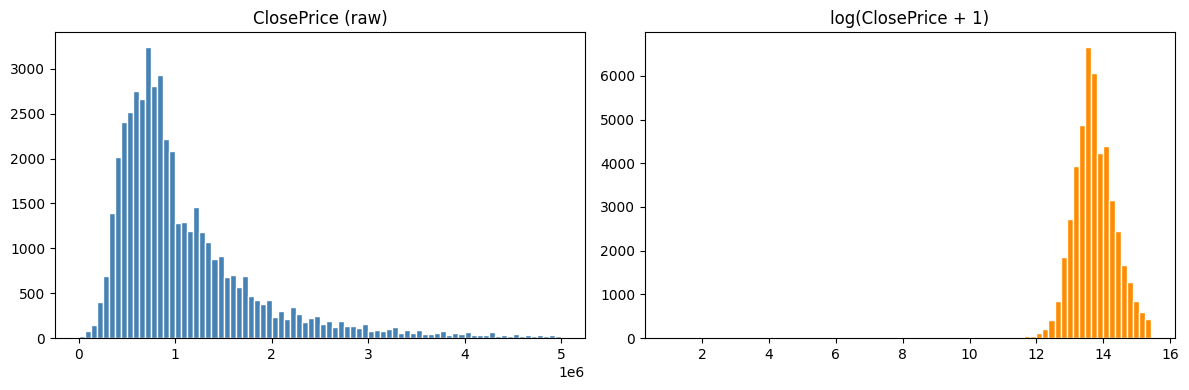

In [75]:
import numpy as np
import matplotlib.pyplot as plt

#visualize the price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('ClosePrice (raw)')
axes[1].hist(np.log1p(y_train), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('log(ClosePrice + 1)')
plt.tight_layout()
plt.show()

Log transformation
- heavily right skewed so apply log transform


In [76]:
y_train_log = np.log1p(y_train)

rf_log = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

lr_log = LinearRegression()

rf_log.fit(X_train, y_train_log)
lr_log.fit(X_train, y_train_log)

rf_pred_log = rf_log.predict(X_val)
lr_pred_log = lr_log.predict(X_val)

# Convert predictions back to dollar prices
rf_pred_price = np.expm1(rf_pred_log)
lr_pred_price = np.expm1(lr_pred_log)

rf_improvement = regression_report(
    y_val,
    rf_pred_price
)

lr_improvement = regression_report(
    y_val,
    lr_pred_price
)

print("Week 4 Improved Random Forest:", rf_improvement)

print("Week 4 Improved Linear Regression:", lr_improvement)

Week 4 Improved Random Forest: {'R2': 0.8729101439941744, 'MAE': 148053.09538579927, 'RMSE': np.float64(268409.41726063617), 'MedianAbsoluteError': np.float64(72607.94214372465), 'MDAPE': np.float64(8.467922172681646)}
Week 4 Improved Linear Regression: {'R2': 0.18966613331120508, 'MAE': 256393.23161346628, 'RMSE': np.float64(677757.4503742821), 'MedianAbsoluteError': np.float64(126335.12405080034), 'MDAPE': np.float64(15.28438422917688)}


## Deliverable

Before and After Table

In [77]:
lr_before_metrics = regression_report(y_val, lr.predict(X_val))
lr_after_metrics = regression_report(y_val, lr_pred_price)

rf_before_metrics = regression_report(y_val, rf.predict(X_val))
rf_after_metrics = regression_report(y_val, rf_pred_price)

pd.DataFrame({
    'Metric': list(rf_before_metrics.keys()),
    'Linear Regression Before': list(lr_before_metrics.values()),
    'Linear Regression After': list(lr_after_metrics.values()),
    'Random Forest Before': list(rf_before_metrics.values()),
    'Random Forest After': list(rf_after_metrics.values())
}).set_index('Metric').round(2)

,Linear Regression Before,Linear Regression After,Random Forest Before,Random Forest After
Metric,,,,
R2,0.80,0.19,0.88,0.87
MAE,211444.63,256393.23,148754.66,148053.10
RMSE,335965.21,677757.45,265567.73,268409.42
MedianAbsoluteError,133189.24,126335.12,72517.60,72607.94
MDAPE,15.28,15.28,8.47,8.47


Linear Regression:


*   Decrease in R² score and increase in RMSE by double
*   Highlights extreme upper bound log predictions that became large dollar errors from np.expm1()


Random Forest:


*   Held steady in all metrics with slight improvement in MAE
* MdAPE remained unchanged, representing that the transformation didn't do an overall improvement.

Actual vs Predicted Plot

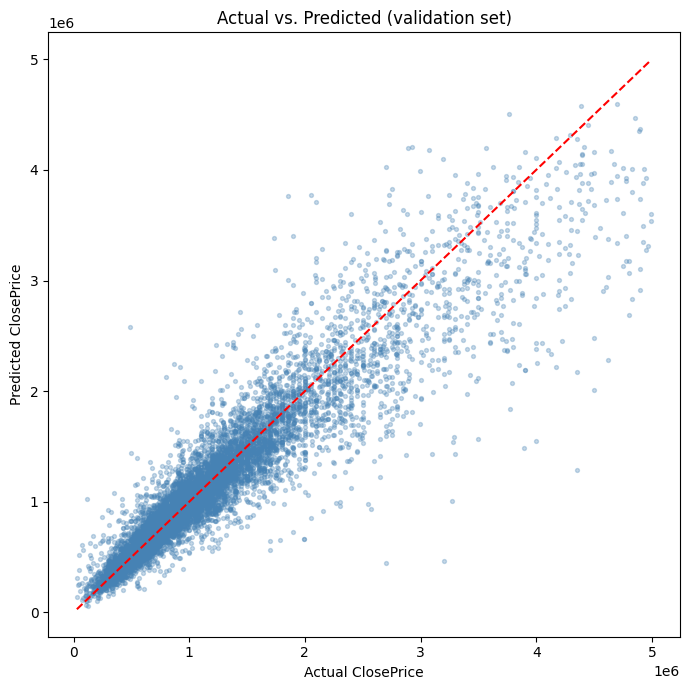

In [78]:
import matplotlib.pyplot as plt

output_dir = data_dir.parent / 'outputs'
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(7, 7))
plt.scatter(y_val, rf_pred_price, alpha=0.3, s=8, color='steelblue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=1.5)
plt.xlabel('Actual ClosePrice')
plt.ylabel('Predicted ClosePrice')
plt.title('Actual vs. Predicted (validation set)')
plt.tight_layout()
plt.savefig(output_dir/'actual_vs_predicted.png', dpi=120)
plt.show()